´´´sentinel-xarray can be tested to access some data´´´ 

In [1]:
%matplotlib inline
from nansat import Nansat
import numpy as np
from openwind.wind_data import fetch_era5_data, preprocess_wind_data
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import urllib3
from tqdm import tqdm
from openwind.auxwind.meps import MEPSFilename, lcc_grid_convergence_angle, process_wind
from pathlib import Path
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [76]:
# Step 1: Define search parameters (time and coordinates) to find ERA5 field
# In case of collocation with Sentinel-1 data these parameters can be extracted from the 
# Sentinel-1 product metadata.
src = '/Data/sat/auxdata/openwind_dev/bergen/S1A_IW_GRDH_1SDV_20220516T055633_20220516T055658_043232_0529BF_BD54.SAFE'
# Read a Sentinel-1 L1 GRD product using Nansat
s1_frame = Nansat(src)
# In order to speed up the processing we will resample the Sentinel-1 product to a pixel size of about 200 m
s1_frame.resize(0.1, resample_alg=1)

0.1

In [59]:
s1_ds = xr.open_dataset(src, engine='sentinel-1', group='IW/VV')
s1_ds_calibration = xr.open_dataset(src, engine='sentinel-1', group='IW/VV/calibration')

/tmp/ipykernel_212080/356997203.py:1: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  s1_ds = xr.open_dataset(src, engine='sentinel-1', group='IW/VV')
/tmp/ipykernel_212080/356997203.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting

In [61]:
s1_ds

<xarray.Dataset> Size: 2GB
Dimensions:       (ground_range: 26525, azimuth_time: 16669)
Coordinates:
    pixel         (ground_range) int64 212kB ...
    line          (azimuth_time) int64 133kB ...
  * azimuth_time  (azimuth_time) datetime64[ns] 133kB 2022-05-16T05:56:33.299...
  * ground_range  (ground_range) float64 212kB 0.0 10.0 ... 2.652e+05 2.652e+05
Data variables:
    measurement   (azimuth_time, ground_range) float32 2GB ...
Attributes: (12/30)
    family_name:                         SENTINEL-1
    number:                              A
    mode:                                IW
    swaths:                              ['IW']
    orbit_number:                        43232
    relative_orbit_number:               110
    ...                                  ...
    geospatial_lon_min:                  3.722554670024245
    geospatial_lon_max:                  8.86065590045546
    group:                               /IW/VV
    subgroups:                           ['orbit', 'attitude', 'azimuth_fm_ra...
    Conventions:                         CF-1.8
    history:                             created by xarray_sentinel-0.9.5

In [77]:
s1_ds_gcp = xr.open_dataset(src, engine='sentinel-1', group='IW/VV/coordinate_conversion')
s1_ds_gcp


/tmp/ipykernel_212080/2952500577.py:1: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  s1_ds_gcp = xr.open_dataset(src, engine='sentinel-1', group='IW/VV/coordinate_conversion')


<xarray.Dataset> Size: 5kB
Dimensions:           (azimuth_time: 28, degree: 9)
Coordinates:
  * azimuth_time      (azimuth_time) datetime64[ns] 224B 2022-05-16T05:56:31....
  * degree            (degree) int64 72B 0 1 2 3 4 5 6 7 8
Data variables:
    gr0               (azimuth_time) float64 224B ...
    sr0               (azimuth_time) float64 224B ...
    slant_range_time  (azimuth_time) float64 224B ...
    srgrCoefficients  (azimuth_time, degree) float64 2kB ...
    grsrCoefficients  (azimuth_time, degree) float64 2kB ...
Attributes: (12/15)
    family_name:                         SENTINEL-1
    number:                              A
    mode:                                IW
    swaths:                              ['IW']
    orbit_number:                        43232
    relative_orbit_number:               110
    ...                                  ...
    product_type:                        GRD
    start_time:                          2022-05-16T05:56:33.299289
    stop_time:                           2022-05-16T05:56:58.297841
    group:                               /IW/VV/coordinate_conversion
    Conventions:                         CF-1.8
    history:                             created by xarray_sentinel-0.9.5

In [40]:
s1_ds_calibration

<xarray.Dataset> Size: 293kB
Dimensions:       (line: 27, pixel: 665)
Coordinates:
  * line          (line) int64 216B 0 667 1334 2000 ... 15335 16002 16669 17336
  * pixel         (pixel) int64 5kB 0 40 80 120 160 ... 26440 26480 26520 26524
Data variables:
    azimuth_time  (line) datetime64[ns] 216B ...
    sigmaNought   (line, pixel) float32 72kB ...
    betaNought    (line, pixel) float32 72kB ...
    gamma         (line, pixel) float32 72kB ...
    dn            (line, pixel) float32 72kB ...
Attributes: (12/17)
    family_name:                         SENTINEL-1
    number:                              A
    mode:                                IW
    swaths:                              ['IW']
    orbit_number:                        43232
    relative_orbit_number:               110
    ...                                  ...
    stop_time:                           2022-05-16T05:56:58.297841
    group:                               /IW/VV/calibration
    Conventions:                         CF-1.8
    title:                               Calibration coefficients
    comment:                             The dataset contains calibration inf...
    history:                             created by xarray_sentinel-0.9.5

In [49]:
import xarray_sentinel
calibrated_data = xarray_sentinel.calibrate_amplitude(s1_ds.measurement, s1_ds_calibration.sigmaNought)

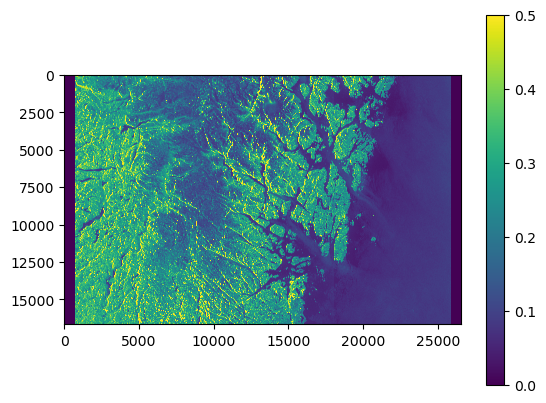

In [50]:
%matplotlib inline
plt.imshow(calibrated_data, clim=[0, 0.5])
plt.colorbar()
plt.show()

In [19]:
s1_lons, s1_lats = s1_frame.get_geolocation_grids()
central_lon = np.nanmean(s1_lons)
central_lat = np.nanmean(s1_lats)

s1_ds = xr.Dataset(
    coords=dict(
        lon=(('azimuth', 'range'), s1_lons),
        lat=(('azimuth', 'range'), s1_lats),
        time=(('time'), [s1_frame.time_coverage_start])),
    data_vars=dict(
        look_direction=(('azimuth', 'range'), s1_frame['look_direction']),
        incidence_angle=(('azimuth', 'range'), s1_frame['incidence_angle']),
    ))

In [21]:
# Construct a OpenDAP uri for the day/time of sentinel-1 acquisition
wind_uri = MEPSFilename(s1_frame.time_coverage_start).assemble_filename()
# Open the time collocated MEPS forecast file 
meps_ds = xr.open_dataset(wind_uri)
# Select the forecast time closest to the sentinel-1 acuisition time
meps_ds = meps_ds.sel(time=s1_frame.time_coverage_start, method='nearest')
# Seect src meps variables 
meps_wind_ds = meps_ds[['x_wind_10m', 'y_wind_10m', 'projection_lambert', 'time']]
# Remove not used MEPS dimensions
meps_wind_ds = meps_wind_ds.squeeze(drop=True)
# Process wind data in the dataset 
meps_wind_ds = process_wind(meps_wind_ds)
# Drop original variables
meps_wind_ds = meps_wind_ds.drop_vars(['longitude', 'latitude', 'x_wind_10m', 'y_wind_10m'])


In [22]:
# Assign projection tothe dataset based on the metadata
meps_wind_ds_ref = meps_wind_ds.rio.write_crs(meps_wind_ds.projection_lambert.proj4, inplace=True)
# Reproject data to lon lat
meps_wind_ds_lonlat = meps_wind_ds_ref.rio.reproject(ccrs.PlateCarree().proj4_init, nodata=999)
# Select the frame from the forecast field based on the the lon lat coordinates
meps_frame = meps_wind_ds_lonlat.sel(x=s1_ds.lon, y=s1_ds.lat, method='nearest')

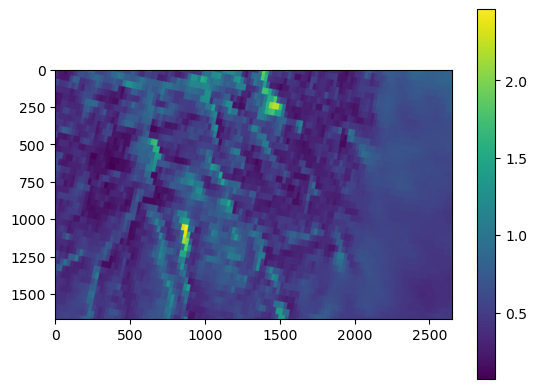

In [23]:
%matplotlib inline
plt.imshow(np.std(meps_frame['wind_speed'].data, axis=0))
plt.colorbar()
plt.show()

In [24]:
def cmod5n_inverse(sigma0_obs, phi, incidence, iterations: int = 10):
    """
    Inverse wind speed from SAR sigma0 and model wind direction.
    This function iterates the forward CMOD5N function until agreement 
    with input (observed) sigma0 values

    :param sigma0_obs: Normalized Radar Cross Section in linear units
    :param phi:        Angle between azimuth and wind direction (phi = D - AZM) in deg.
    :param incidence:  Incidence angle in deg.
    :param iterations: Number of iterations to run

    :returns V:        Wind speed at 10 m height in m/s, neutral stratification
    """    
    # First guess wind speed
    V = np.full(sigma0_obs.shape, 10)
    step = 3
    
    # Iterating until error is smaller than threshold
    for iterno in tqdm(range(1, iterations), total=len(range(1, iterations))):
        sigma0_calc = cmod5n_forward(V, phi, incidence)
        ind = sigma0_calc - sigma0_obs > 0
        V = V + step
        V[ind] = V[ind] - 2*step 
        step = step/2
    return V
    

In [28]:
phi = np.mod(meps_frame.wind_direction[0,:,:].data - s1_ds.look_direction.data, 360)

In [ ]:
sar_wind_spd = cmod5n_inverse(ds.sigma0.data[:, 100:-100], phi, ds.angle_of_incidence.data[:, 100:-100], iterations=10,)

In [ ]:
phi = np.mod(meps_frame.wind_direection.data[:, 100:-100] - s1_ds.look_direction.data[:, 100:-100], 360)


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:08<00:00,  1.12it/s]


In [5]:
# Find and download ERA5 data
# Artem 6 Mar 2024 - Data request takes very long time due to new CDS system migration 
era5_uri = fetch_era5_data(s1_time, central_lat, central_lon, '/src/.devcontainer/')

>> Downloading /src/.devcontainer/ERA5_20220516T0600.nc


2024-08-12 07:00:36,553 INFO Welcome to the CDS.
 As per our announcements on the Forum, this instance of CDS will soon be decommissioned.
 Please update your cdsapi package to a version >=0.7.0, create an account on CDS-Beta and update your .cdsapirc file. We strongly recommend users to check our Guidelines at https://confluence.ecmwf.int/x/uINmFw
 The current legacy system will be kept for a while, but we will reduce resources gradually until full decommissioning in September 2024.
2024-08-12 07:00:36,553 WARNING MOVE TO CDS-Beta
2024-08-12 07:00:36,554 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2024-08-12 07:00:36,668 INFO Request is completed
2024-08-12 07:00:36,669 INFO Downloading https://download-0014-clone.copernicus-climate.eu/cache-compute-0014/cache/data3/adaptor.mars.internal-1723445930.5738049-27398-9-7ee47acb-f806-4f46-b881-07ebc8bd2e31.nc to /src/.devcontainer/ERA5_20220516T0600.nc (8.2K)
2024-08-12 07:00:36,9

In [28]:
# Derive wind speed and direction from the model
era5_uri = 'ERA5_20220110T1800.nc'
wind_spd, wind_dir = preprocess_wind_data(era5_uri, dst_geometry=s1_frame)

>> Reading ERA5_20220110T1800.nc


Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
/opt/conda/lib/python3.11/site-packages/nansat-1.6.0-py3.11-linux-x86_64.egg/nansat/mappers/mapper_netcdf_cf.py:393: UserWarning: GDAL cannot determine the dataset projection - using Nansat spatial reference WKT, assuming a regular longitude/latitude grid
  warnings.warn('GDAL cannot determine the dataset projection - using Nansat ' \
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.

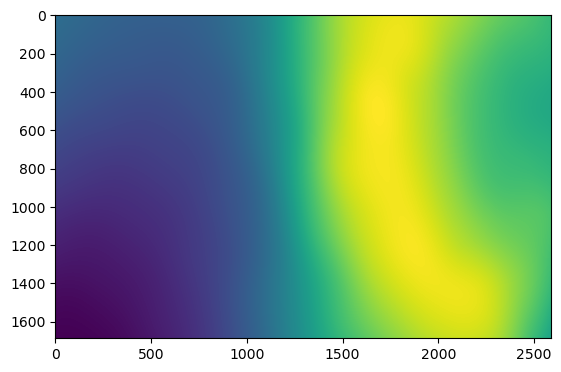

In [29]:
%matplotlib inline
plt.imshow(wind_dir)

In [31]:
import xarray as xr
import pythesint as pti
d = xr.open_dataset('/src/tutorial/S1A_IW_GRDH_1SDV_20220110T173429_20220110T173454_041401_04EC3B_31E4.nc')

In [32]:
wind_spd_meta = pti.get_cf_standard_name('wind_speed')
wind_spd_meta['source'] = 'ERA5'
wind_spd_meta['_FillValue'] = -999.

wind_dir_meta = pti.get_cf_standard_name('wind_from_direction')
wind_dir_meta['source'] = 'ERA5'
wind_dir_meta['_FillValue'] = -999.


d['wind_spd'] = xr.Variable(('row', 'col'), wind_spd, wind_spd_meta)
d['wind_dir'] = xr.Variable(('row', 'col'), wind_dir, wind_dir_meta)

ValueError: conflicting sizes for dimension 'row': length 1687 on 'wind_spd' and length 1698 on {'row': 'sigma0_s1dn', 'col': 'sigma0_s1dn'}

In [21]:
d

<xarray.Dataset> Size: 210MB
Dimensions:             (row: 1687, col: 2590)
Coordinates:
    lat                 (row, col) float64 35MB ...
    lon                 (row, col) float64 35MB ...
Dimensions without coordinates: row, col
Data variables:
    sigma0_s1dn         (row, col) float32 17MB ...
    sigma0              (row, col) float32 17MB ...
    angle_of_incidence  (row, col) float64 35MB ...
    look_direction      (row, col) float32 17MB ...
    watermask           (row, col) float32 17MB ...
    wind_spd            (row, col) float32 17MB 5.713 5.711 5.71 ... 2.577 2.575
    wind_dir            (row, col) float32 17MB 271.9 271.9 ... 290.7 290.6
Attributes:
    data_center:          {"Bucket_Level0": "MULTINATIONAL ORGANIZATIONS", "B...
    entry_id:             S1A_IW_GRDH_1SDV_20220110T173429_20220110T173454_04...
    entry_title:          SENTINEL-1A SAR
    filename:             /vsimem/U4TWXTJXHY.vrt
    instrument:           {"Category": "Earth Remote Sensing Instruments", "C...
    iso_topic_category:   {"iso_topic_category": "Oceans"}
    platform:             {"Basis": "Space-based Platforms", "Category": "Ear...
    summary:              SENTINEL-1A SAR data
    time_coverage_end:    2022-01-10T17:34:54.365408
    time_coverage_start:  2022-01-10T17:34:29.367288

In [22]:
d.to_netcdf('test.nc')

OrderedDict([('standard_name', 'wind_speed'),
             ('canonical_units', 'm s-1'),
             ('definition',
              'Speed is the magnitude of velocity. Wind is defined as a two-dimensional (horizontal) air velocity vector, with no vertical component. (Vertical motion in the atmosphere has the standard name upward_air_velocity.) The wind speed is the magnitude of the wind velocity.')])

In [27]:
d

<xarray.Dataset> Size: 175MB
Dimensions:             (row: 1687, col: 2590)
Coordinates:
    lat                 (row, col) float64 35MB ...
    lon                 (row, col) float64 35MB ...
Dimensions without coordinates: row, col
Data variables:
    sigma0              (row, col) float32 17MB ...
    angle_of_incidence  (row, col) float64 35MB ...
    look_direction      (row, col) float32 17MB ...
    wind_spd            (row, col) float32 17MB 5.713 5.711 5.71 ... 2.577 2.575
    wind_dir            (row, col) float32 17MB 271.9 271.9 ... 290.7 290.6
Attributes:
    data_center:          {"Bucket_Level0": "MULTINATIONAL ORGANIZATIONS", "B...
    entry_id:             S1A_IW_GRDH_1SDV_20220110T173429_20220110T173454_04...
    entry_title:          SENTINEL-1A SAR
    filename:             /vsimem/5GTW3EVT0C.vrt
    instrument:           {"Category": "Earth Remote Sensing Instruments", "C...
    iso_topic_category:   {"iso_topic_category": "Oceans"}
    platform:             {"Basis": "Space-based Platforms", "Category": "Ear...
    summary:              SENTINEL-1A SAR data
    time_coverage_end:    2022-01-10T17:34:54.365408
    time_coverage_start:  2022-01-10T17:34:29.367288